# Using `blsutils` package

This notebook demonstrates how to use my custom `blsutils` package (not on pypi) to obtain number of jobs added on a 1-month or month-to-month basis.  You need to have your own BLS developer API key and also have the series ID you want to plot.  It is assumed you have a `.env` file with "BLS_API_KEY=" assigned.  The series ID for all jobs added, seasonally adjusted is "CES0000000001".

In [1]:
from blsutils import BLSClient
import matplotlib.pyplot as plt
import polars as pl

### Let's look at jobs added trend from 2007 thru 2026 so that we can include 2008-2009 Recession Period, Pre-COVID, COVID, and recent data

**NOTE:** BLS provides a maximum of 19 years of data.  If we set start year of 2006, 2026 would not be provided, but 2025's data instead. 

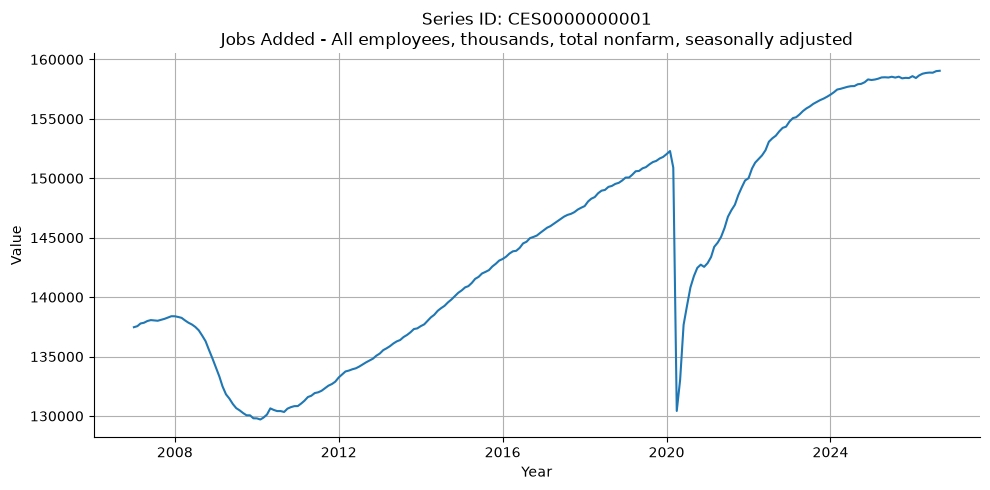

shape: (5, 5)
┌───────────────┬────────────┬──────┬────────┬──────────┐
│ series_id     ┆ year_month ┆ year ┆ period ┆ value    │
│ ---           ┆ ---        ┆ ---  ┆ ---    ┆ ---      │
│ str           ┆ date       ┆ str  ┆ str    ┆ f64      │
╞═══════════════╪════════════╪══════╪════════╪══════════╡
│ CES0000000001 ┆ 2026-05-01 ┆ 2026 ┆ M05    ┆ 158861.0 │
│ CES0000000001 ┆ 2026-06-01 ┆ 2026 ┆ M06    ┆ 158892.0 │
│ CES0000000001 ┆ 2026-07-01 ┆ 2026 ┆ M07    ┆ 158882.0 │
│ CES0000000001 ┆ 2026-08-01 ┆ 2026 ┆ M08    ┆ 159015.0 │
│ CES0000000001 ┆ 2026-09-01 ┆ 2026 ┆ M09    ┆ 159044.0 │
└───────────────┴────────────┴──────┴────────┴──────────┘


In [2]:
with BLSClient() as client:
    df = client.fetch_df(series_id="CES0000000001", start_year=2007, end_year=2026)
    client.plot_bls_series(df, "Jobs Added - All employees, thousands, total nonfarm, seasonally adjusted")
    print(df.tail())

There was a little bit of up-tick for 2026, but the slope or trend is very low compared to pre-COVID.

#### To show BLS only provides maximum of 19 years worth of data, if we set start year of 2006, we can see that 2026 data is missing, and we have data through end of 2025:

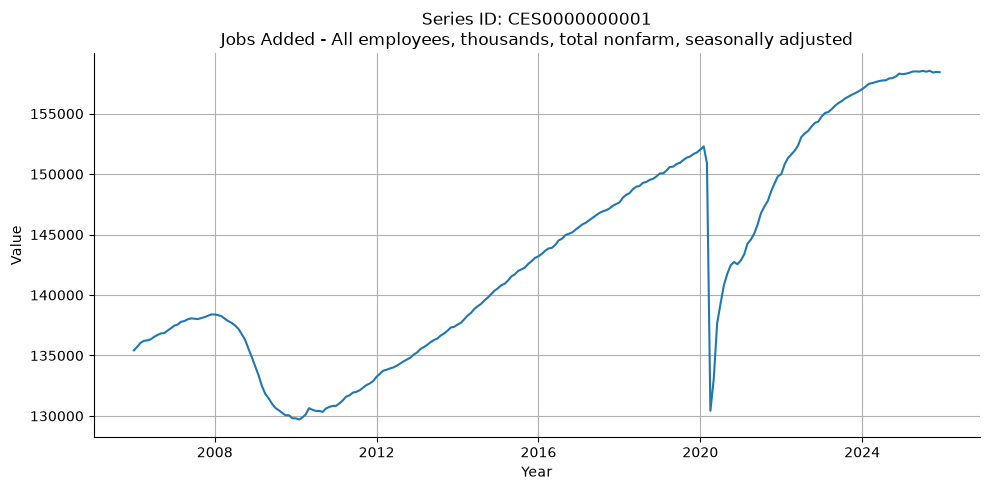

shape: (5, 5)
┌───────────────┬────────────┬──────┬────────┬──────────┐
│ series_id     ┆ year_month ┆ year ┆ period ┆ value    │
│ ---           ┆ ---        ┆ ---  ┆ ---    ┆ ---      │
│ str           ┆ date       ┆ str  ┆ str    ┆ f64      │
╞═══════════════╪════════════╪══════╪════════╪══════════╡
│ CES0000000001 ┆ 2025-08-01 ┆ 2025 ┆ M08    ┆ 158472.0 │
│ CES0000000001 ┆ 2025-09-01 ┆ 2025 ┆ M09    ┆ 158548.0 │
│ CES0000000001 ┆ 2025-10-01 ┆ 2025 ┆ M10    ┆ 158408.0 │
│ CES0000000001 ┆ 2025-11-01 ┆ 2025 ┆ M11    ┆ 158449.0 │
│ CES0000000001 ┆ 2025-12-01 ┆ 2025 ┆ M12    ┆ 158432.0 │
└───────────────┴────────────┴──────┴────────┴──────────┘


In [3]:
with BLSClient() as client:
    df = client.fetch_df(series_id="CES0000000001", start_year=2006, end_year=2026)
    client.plot_bls_series(df, "Jobs Added - All employees, thousands, total nonfarm, seasonally adjusted")
    print(df.tail())

#### Let's take population into account (16 year old and over) using series ID "LNS12300000"

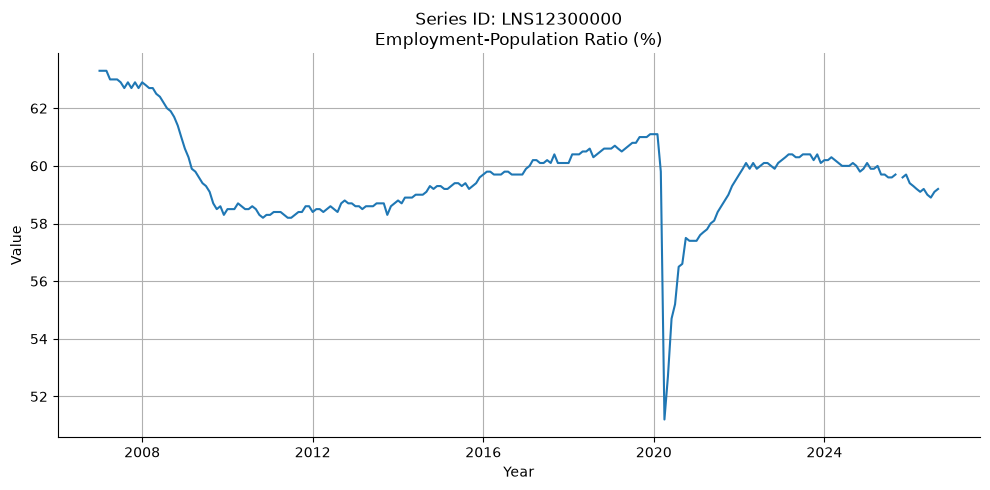

shape: (5, 5)
┌─────────────┬────────────┬──────┬────────┬───────┐
│ series_id   ┆ year_month ┆ year ┆ period ┆ value │
│ ---         ┆ ---        ┆ ---  ┆ ---    ┆ ---   │
│ str         ┆ date       ┆ str  ┆ str    ┆ f64   │
╞═════════════╪════════════╪══════╪════════╪═══════╡
│ LNS12300000 ┆ 2026-05-01 ┆ 2026 ┆ M05    ┆ 59.2  │
│ LNS12300000 ┆ 2026-06-01 ┆ 2026 ┆ M06    ┆ 59.0  │
│ LNS12300000 ┆ 2026-07-01 ┆ 2026 ┆ M07    ┆ 58.9  │
│ LNS12300000 ┆ 2026-08-01 ┆ 2026 ┆ M08    ┆ 59.1  │
│ LNS12300000 ┆ 2026-09-01 ┆ 2026 ┆ M09    ┆ 59.2  │
└─────────────┴────────────┴──────┴────────┴───────┘


In [4]:
with BLSClient() as client:
    df = client.fetch_df(series_id="LNS12300000", start_year=2007, end_year=2026)
    client.plot_bls_series(df, "Employment-Population Ratio (%)")
    print(df.tail())

When taking into account population level, we are at a downward trend.  Pre-COVID, the trend was upwards.